In [11]:
#import libraries
import torch 
import torch.nn as nn 
import torch.optim as optim
from torchvision import datasets,  transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np



In [2]:
device =  torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
#data into train and val 
BATCH_SIZE = 128
data_transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root= "./data",  train= True, transform= data_transform, download=True)
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle=True)

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.84MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 94.8kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 865kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.22MB/s]


In [9]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim = 32, hidden_dim = 256):
        super().__init__()
    #encoder
        self.encoder = nn.Sequential(
            nn.Linear(784,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU()

        )
    #Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 784),
            nn.Sigmoid()

        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon
    


In [12]:
#defining the model, loss
model = AutoEncoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-3)

In [14]:
epochs =5
model.train()
for epoch in range(epochs):
    total_loss = 0
    for x,_ in train_loader:
        x = x.view(-1,784).to(device)
        optimizer.zero_grad()

        x_recon = model(x)
        loss = criterion(x_recon,x)
        loss.backward()
        optimizer.step()
        total_loss+= loss.item()
    avg_loss = total_loss/len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}],Loss:{avg_loss:.6f}")

Epoch [1/5],Loss:0.043269
Epoch [2/5],Loss:0.018013
Epoch [3/5],Loss:0.014146
Epoch [4/5],Loss:0.012609
Epoch [5/5],Loss:0.011747


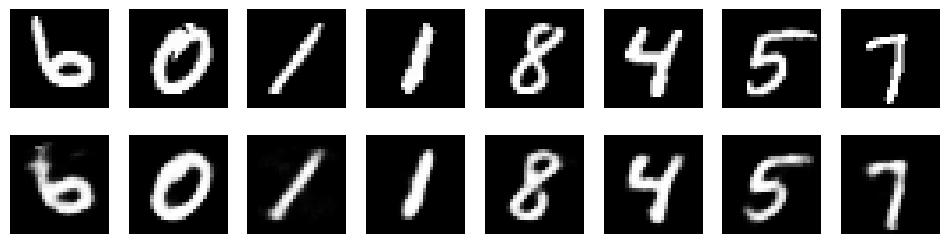

In [17]:
model.eval()
with torch.no_grad():
    x,_=next(iter(train_loader))
    x = x.view(-1,784).to(device)
    x_recon =model(x)
    x = x.cpu()
    n = 8 
    plt.figure(figsize =(12,3))
    for i in range(n):
        plt.subplot(2,n,i+1)
        plt.imshow(x[i].view(28,28),cmap="gray")
        plt.axis("off")

        plt.subplot(2,n,i+1+n)
        plt.imshow(x_recon[i].view(28,28), cmap="gray")
        plt.axis("off")
    plt.show()